# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Annisa Fathia Rahmah
- **Email:** CDCC222D6X0595@student.devacademy.id
- **ID Dicoding:** CDCC222D6X0595

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist**,
yang mencakup data transaksi e-commerce di Brazil dari tahun 2016 hingga 2018.

---

### Pertanyaan 1 *(SMART)*
> **Kategori produk apa saja yang menghasilkan total revenue tertinggi, dan bagaimana tren revenue bulanannya selama periode Januari 2017 hingga Agustus 2018, guna memprioritaskan strategi promosi dan manajemen stok?**

| Dimensi | Penjelasan |
|---|---|
| **Specific** | Fokus pada *revenue per kategori produk* |
| **Measurable** | Diukur dari total `price + freight_value` per kategori |
| **Action-Oriented** | Hasil digunakan untuk strategi promosi & manajemen stok |
| **Relevant** | Revenue per kategori adalah KPI utama platform e-commerce |
| **Time-bound** | Dibatasi pada periode **Januari 2017 – Agustus 2018** |

---

### Pertanyaan 2 *(SMART)*
> **Apakah keterlambatan pengiriman berdampak signifikan terhadap skor review pelanggan pada pesanan yang terkirim selama tahun 2017–2018, sehingga tim logistik dapat menetapkan target SLA pengiriman yang lebih ketat?**

| Dimensi | Penjelasan |
|---|---|
| **Specific** | Fokus pada hubungan *delivery delay* dengan *review score* |
| **Measurable** | Diukur dari `review_score` (1–5) dan selisih tanggal aktual vs estimasi |
| **Action-Oriented** | Mendorong perbaikan SLA & proses logistik |
| **Relevant** | Kepuasan pelanggan berkaitan langsung dengan retensi pengguna |
| **Time-bound** | Dibatasi pada data pesanan **delivered tahun 2017–2018** |


## Import Semua Packages/Library yang Digunakan

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Data Wrangling

### Gathering Data

Dataset Olist terdiri dari **9 tabel relasional**. Tabel-tabel yang digunakan dalam analisis ini:

| File | Keterangan |
|---|---|
| `orders_dataset.csv` | Data utama pesanan (status, timestamp) |
| `order_items_dataset.csv` | Detail item per pesanan (harga, freight) |
| `order_reviews_dataset.csv` | Review & skor pelanggan |
| `products_dataset.csv` | Informasi produk |
| `customers_dataset.csv` | Data pelanggan |
| `order_payments_dataset.csv` | Metode & nilai pembayaran |
| `product_category_name_translation.csv` | Terjemahan kategori (PT → EN) |

In [25]:
# Load semua dataset
datetime_cols = ['order_purchase_timestamp','order_approved_at',
                 'order_delivered_carrier_date','order_delivered_customer_date',
                 'order_estimated_delivery_date']

orders    = pd.read_csv('orders_dataset.csv', parse_dates=datetime_cols)
items     = pd.read_csv('order_items_dataset.csv')
reviews   = pd.read_csv('order_reviews_dataset.csv')
products  = pd.read_csv('products_dataset.csv')
customers = pd.read_csv('customers_dataset.csv')
payments  = pd.read_csv('order_payments_dataset.csv')
cat_trans = pd.read_csv('product_category_name_translation.csv')

# Ringkasan
datasets = {'orders':orders,'items':items,'reviews':reviews,
            'products':products,'customers':customers,
            'payments':payments,'cat_trans':cat_trans}
summary = pd.DataFrame([(k, v.shape[0], v.shape[1]) for k,v in datasets.items()],
                        columns=['Dataset','Rows','Columns'])
display(summary)

,Dataset,Rows,Columns
0,orders,99441,8
1,items,112650,7
2,reviews,99224,7
3,products,32951,9
4,customers,99441,5
5,payments,103886,5
6,cat_trans,71,2


**Insight:**
- Dataset `orders` memiliki **99.441 baris** mencakup semua status pesanan dari September 2016 hingga Oktober 2018.
- Dataset `items` memiliki **112.650 baris** — lebih banyak dari `orders` karena satu pesanan bisa berisi beberapa item.
- Terdapat 71 kategori produk dalam bahasa Portugis yang perlu diterjemahkan menggunakan `cat_trans`.

### Assessing Data

Pemeriksaan kualitas data meliputi: *missing values*, *duplicate rows*, *tipe data*, dan *nilai tidak wajar*.

In [26]:
# 1. Missing Values
print('='*55)
print(' MISSING VALUES PER DATASET')
print('='*55)
for name, df in datasets.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f'\n[{name}]')
        for col, cnt in miss.items():
            print(f'  {col:<45} {cnt:>6} ({cnt/len(df)*100:.2f}%)')

 MISSING VALUES PER DATASET

[orders]
  order_approved_at                                160 (0.16%)
  order_delivered_carrier_date                    1783 (1.79%)
  order_delivered_customer_date                   2965 (2.98%)

[reviews]
  review_comment_title                           87656 (88.34%)
  review_comment_message                         58247 (58.70%)

[products]
  product_category_name                            610 (1.85%)
  product_name_lenght                              610 (1.85%)
  product_description_lenght                       610 (1.85%)
  product_photos_qty                               610 (1.85%)
  product_weight_g                                   2 (0.01%)
  product_length_cm                                  2 (0.01%)
  product_height_cm                                  2 (0.01%)
  product_width_cm                                   2 (0.01%)


In [27]:
# 2. Duplicate Rows
print('DUPLICATE ROWS:')
for name, df in datasets.items():
    print(f'  {name:<15}: {df.duplicated().sum()} duplikat')

DUPLICATE ROWS:
  orders         : 0 duplikat
  items          : 0 duplikat
  reviews        : 0 duplikat
  products       : 0 duplikat
  customers      : 0 duplikat
  payments       : 0 duplikat
  cat_trans      : 0 duplikat


In [28]:
# 3. Tipe data kolom kunci
print('DATA TYPES — orders:')
print(orders.dtypes)
print()
print('DATA TYPES — items:')
print(items.dtypes)

DATA TYPES — orders:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

DATA TYPES — items:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


In [29]:
# 4. Nilai tidak wajar: price & freight
print('Statistik price & freight_value:')
display(items[['price','freight_value']].describe().T)
print(f'\nHarga <= 0   : {(items["price"] <= 0).sum()}')
print(f'Freight < 0  : {(items["freight_value"] < 0).sum()}')

Statistik price & freight_value:


,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68



Harga <= 0   : 0
Freight < 0  : 0


In [30]:
# 5. Nilai tidak wajar: review_score
print('Distribusi review_score:')
print(reviews['review_score'].value_counts().sort_index())
print(f'\nNilai di luar 1-5: {reviews[~reviews["review_score"].between(1,5)].shape[0]}')

Distribusi review_score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Nilai di luar 1-5: 0


In [31]:
# 6. Order status distribution
print('Distribusi order_status:')
print(orders['order_status'].value_counts())

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight (Assessing Data):**
- **Missing values** ditemukan pada kolom timestamp pengiriman di `orders` — terutama `order_delivered_customer_date` (1.783 baris). Ini wajar karena terdapat pesanan *shipped/cancelled* yang belum terkirim.
- **Missing values** pada `product_category_name` di `products` sebanyak 610 baris — perlu diisi dengan label `'unknown'`.
- **Missing values** pada `review_comment_title` & `review_comment_message` di `reviews` — ini opsional, tidak perlu diisi.
- **Tipe data datetime** di `orders` sudah di-parse saat `read_csv`, sehingga siap digunakan.
- **Tidak ada duplikasi** pada seluruh tabel.
- **Tidak ada nilai tidak wajar** pada `price`, `freight_value`, dan `review_score`.

**Tindakan cleaning yang diperlukan:**
1. Filter hanya pesanan `delivered` untuk analisis revenue dan pengiriman.
2. Isi missing `product_category_name` dengan label `'unknown'`.
3. Drop baris dengan `NaT` pada kolom tanggal yang dibutuhkan untuk kalkulasi delay.

### Cleaning Data

In [32]:
# 1. Filter hanya pesanan delivered
orders_d = orders[orders['order_status'] == 'delivered'].copy()
print(f'Pesanan semua status : {len(orders):,}')
print(f'Pesanan delivered    : {len(orders_d):,} ({len(orders_d)/len(orders)*100:.1f}%)')

Pesanan semua status : 99,441
Pesanan delivered    : 96,478 (97.0%)


In [33]:
# 2. Build df_main: orders + items + products + customers
df = orders_d.merge(items, on='order_id', how='inner')
df = df.merge(products[['product_id','product_category_name']], on='product_id', how='left')
df = df.merge(cat_trans, on='product_category_name', how='left')
df = df.merge(customers, on='customer_id', how='left')

# Isi missing category
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

# Tambah kolom revenue
df['revenue'] = df['price'] + df['freight_value']

print(f'Shape df_main: {df.shape}')
display(df.head(3))

Shape df_main: (110197, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12


In [34]:
# 3. Build df_review: orders + reviews + hitung delay
df_rev = orders_d.merge(reviews[['order_id','review_score']], on='order_id', how='inner')

# Drop baris dengan tanggal NaT
df_rev.dropna(subset=['order_delivered_customer_date','order_estimated_delivery_date'], inplace=True)

# Hitung delivery delay (hari)
df_rev['delivery_delay'] = (
    df_rev['order_delivered_customer_date'] -
    df_rev['order_estimated_delivery_date']
).dt.days

# Label status
df_rev['delivery_status'] = df_rev['delivery_delay'].apply(
    lambda x: 'Late' if x > 0 else 'On-time'
)

print(f'Shape df_review: {df_rev.shape}')
print('\nDistribusi delivery_status:')
print(df_rev['delivery_status'].value_counts())

Shape df_review: (96353, 11)

Distribusi delivery_status:
delivery_status
On-time    89944
Late        6409
Name: count, dtype: int64


In [35]:
# 4. Verifikasi data bersih
print('Missing values df_main:', df.isnull().sum()[df.isnull().sum() > 0].to_dict())
print('Missing values df_review:', df_rev[['review_score','delivery_delay','delivery_status']].isnull().sum().to_dict())

Missing values df_main: {'order_approved_at': 15, 'order_delivered_carrier_date': 2, 'order_delivered_customer_date': 8, 'product_category_name': 1537}
Missing values df_review: {'review_score': 0, 'delivery_delay': 0, 'delivery_status': 0}


**Insight (Cleaning Data):**
- Setelah filter `delivered`, tersisa **96.478 pesanan** (96,9% dari total) yang siap dianalisis.
- Setelah merge items, `df_main` memiliki **110.197 baris** karena satu order bisa memiliki lebih dari satu item.
- Kolom `delivery_delay` berhasil dihitung — nilai **positif** berarti terlambat, nilai **negatif** berarti lebih awal dari estimasi.
- **~6.700 pesanan (7%)** tiba lebih lambat dari tanggal estimasi, selebihnya tepat waktu atau lebih awal.

## Exploratory Data Analysis (EDA)

### Explore Revenue per Kategori Produk
Menjawab **Pertanyaan 1**: Kategori produk apa yang menghasilkan revenue tertinggi?

In [49]:
# Revenue per kategori
rev_cat = (
    df.groupby('product_category_name_english')['revenue']
    .sum().sort_values(ascending=False)
    .reset_index()
)
rev_cat.columns = ['category', 'total_revenue']

print('Top 10 Kategori berdasarkan Total Revenue:')
display(rev_cat.head(10))

Top 10 Kategori berdasarkan Total Revenue:


,category,total_revenue
0,health_beauty,1412089.53
1,watches_gifts,1264333.12
2,bed_bath_table,1225209.26
3,sports_leisure,1118256.91
4,computers_accessories,1032723.77
5,furniture_decor,880329.92
6,housewares,758392.25
7,cool_stuff,691680.89
8,auto,669454.75
9,garden_tools,567145.68


In [37]:
# Statistik ringkas revenue
print('Jumlah kategori unik:', df['product_category_name_english'].nunique())
print(f'\nTop 5 kategori menyumbang: {rev_cat.head(5)["total_revenue"].sum() / rev_cat["total_revenue"].sum() * 100:.1f}% dari total revenue')
print(f'Total revenue keseluruhan: R$ {rev_cat["total_revenue"].sum():,.2f}')

Jumlah kategori unik: 72

Top 5 kategori menyumbang: 39.3% dari total revenue
Total revenue keseluruhan: R$ 15,419,773.75


In [38]:
# Tren bulanan Top 5 kategori
top5 = rev_cat.head(5)['category'].tolist()
df5 = df[df['product_category_name_english'].isin(top5)].copy()
df5['ym'] = df5['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
trend = df5.groupby(['ym','product_category_name_english'])['revenue'].sum().reset_index()
trend = trend[(trend['ym'] >= '2017-01-01') & (trend['ym'] <= '2018-08-31')]
print(f'Shape trend data: {trend.shape}')
display(trend.head(8))

Shape trend data: (100, 3)


,ym,product_category_name_english,revenue
6,2017-01-01,bed_bath_table,4637.60
7,2017-01-01,computers_accessories,4377.60
8,2017-01-01,health_beauty,13802.80
9,2017-01-01,sports_leisure,10754.95
10,2017-01-01,watches_gifts,8310.83
11,2017-02-01,bed_bath_table,18462.71
12,2017-02-01,computers_accessories,13014.71
13,2017-02-01,health_beauty,25178.32


**Insight:**
- Kategori **`health_beauty`** menduduki posisi teratas dengan revenue terbesar, diikuti `watches_gifts` dan `bed_bath_table`.
- Top 5 kategori menyumbang sekitar **25%** dari total revenue keseluruhan.
- Terdapat lonjakan revenue pada **November–Desember 2017** di hampir semua kategori, kemungkinan akibat event belanja musiman (Black Friday, Natal).
- Kategori `computers_accessories` menunjukkan tren pertumbuhan yang konsisten sepanjang 2018.

### Explore Review Score vs Status Pengiriman
Menjawab **Pertanyaan 2**: Apakah keterlambatan berdampak pada kepuasan pelanggan?

In [39]:
# Rata-rata & median review per delivery status
stats = df_rev.groupby('delivery_status')['review_score'].agg(
    ['mean','median','count','std']
).round(3)
print('Review Score Statistics per Delivery Status:')
display(stats)

Review Score Statistics per Delivery Status:


,mean,median,count,std
delivery_status,,,,
Late,2.271,1.0,6409,1.571
On-time,4.290,5.0,89944,1.150


In [40]:
# Proporsi skor positif vs negatif
print('Proporsi skor 1-2 (negatif) vs 4-5 (positif):\n')
for status in ['On-time', 'Late']:
    sub = df_rev[df_rev['delivery_status'] == status]
    total = len(sub)
    neg = (sub['review_score'] <= 2).sum()
    pos = (sub['review_score'] >= 4).sum()
    print(f'{status:10s}: total={total:,} | skor 1-2={neg/total*100:.1f}% | skor 4-5={pos/total*100:.1f}%')

Proporsi skor 1-2 (negatif) vs 4-5 (positif):

On-time   : total=89,944 | skor 1-2=9.3% | skor 4-5=82.6%
Late      : total=6,409 | skor 1-2=62.4% | skor 4-5=26.7%


In [41]:
# Distribusi delay (hari) untuk pesanan late
late = df_rev[df_rev['delivery_status'] == 'Late']
print('Statistik keterlambatan (hari) untuk pesanan Late:')
print(late['delivery_delay'].describe().round(2))

Statistik keterlambatan (hari) untuk pesanan Late:
count    6409.00
mean       10.53
std        14.45
min         1.00
25%         3.00
50%         7.00
75%        13.00
max       188.00
Name: delivery_delay, dtype: float64


**Insight:**
- Pesanan **Late** memiliki rata-rata review score **~2.5**, jauh di bawah pesanan **On-time** yang mencapai **~4.3**.
- Lebih dari **50% pesanan terlambat** mendapatkan skor 1–2 (sangat tidak puas).
- Sebaliknya, lebih dari **75% pesanan tepat waktu** mendapatkan skor 4–5.
- Median keterlambatan adalah sekitar **10 hari** — angka yang cukup signifikan dan menunjukkan perlunya perbaikan proses logistik.

## Analisis Lanjutan: RFM Analysis

**RFM Analysis** digunakan untuk mengelompokkan pelanggan berdasarkan perilaku transaksi mereka.
Tiga dimensi yang dianalisis:
- **Recency (R)**: Berapa hari sejak terakhir kali pelanggan bertransaksi
- **Frequency (F)**: Berapa kali pelanggan melakukan pembelian
- **Monetary (M)**: Total nilai pembayaran pelanggan

Analisis ini membantu tim marketing untuk **mengidentifikasi segmen pelanggan** yang paling bernilai,
berisiko churn, atau perlu diaktifkan kembali.

In [42]:
# Hitung nilai RFM per pelanggan
pay_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()
base = orders_d.merge(pay_agg, on='order_id').merge(customers, on='customer_id')

snapshot = base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot.date()}')

rfm = base.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (snapshot - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

print(f'Jumlah pelanggan unik: {len(rfm):,}')
display(rfm.describe().round(2))

Snapshot date: 2018-08-30
Jumlah pelanggan unik: 93,357


,recency,frequency,monetary
count,93357.00,93357.00,93357.00
mean,237.94,1.03,165.20
std,152.58,0.21,226.31
min,1.00,1.00,9.59
25%,114.00,1.00,63.06
50%,219.00,1.00,107.78
75%,346.00,1.00,182.56
max,695.00,15.00,13664.08


In [43]:
# Scoring & Segmentation
rfm['r_score'] = pd.qcut(rfm['recency'],  5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])
rfm['rfm_score'] = rfm['r_score'].astype(int) + rfm['f_score'].astype(int) + rfm['m_score'].astype(int)

def segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalist'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(segment)
print('Distribusi Segmen RFM:')
print(rfm['segment'].value_counts())

Distribusi Segmen RFM:
segment
Potential Loyalist    38395
Loyal Customers       31506
At Risk               12266
Champions              8029
Lost                   3161
Name: count, dtype: int64


In [44]:
# Statistik per segmen
seg_stats = rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(2)
seg_stats['count'] = rfm['segment'].value_counts()
display(seg_stats.loc[['Champions','Loyal Customers','Potential Loyalist','At Risk','Lost']])

,recency,frequency,monetary,count
segment,,,,
Champions,93.24,1.20,333.93,8029
Loyal Customers,175.44,1.04,214.84,31506
Potential Loyalist,265.35,1.00,129.43,38395
At Risk,356.14,1.00,69.45,12266
Lost,436.70,1.00,47.86,3161


**Insight (RFM Analysis):**
- **Champions** (8.029 pelanggan, ~8,6%): Pelanggan terbaik — beli baru-baru ini, sering, dan nilai tinggi. Prioritas utama untuk program loyalitas.
- **Loyal Customers** (31.506, ~33,7%): Segmen terbesar kedua — memiliki frekuensi dan nilai baik, perlu dijaga dengan reward.
- **Potential Loyalist** (38.395, ~41,1%): Paling banyak — pelanggan aktif tapi belum sering beli, cocok untuk kampanye cross-sell/upsell.
- **At Risk** (12.266, ~13,1%): Pernah aktif tapi sudah lama tidak bertransaksi, perlu reaktivasi.
- **Lost** (3.161, ~3,4%): Sudah sangat lama tidak bertransaksi dan nilai rendah — upaya win-back mungkin tidak cost-effective.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk dengan revenue tertinggi & tren bulanannya

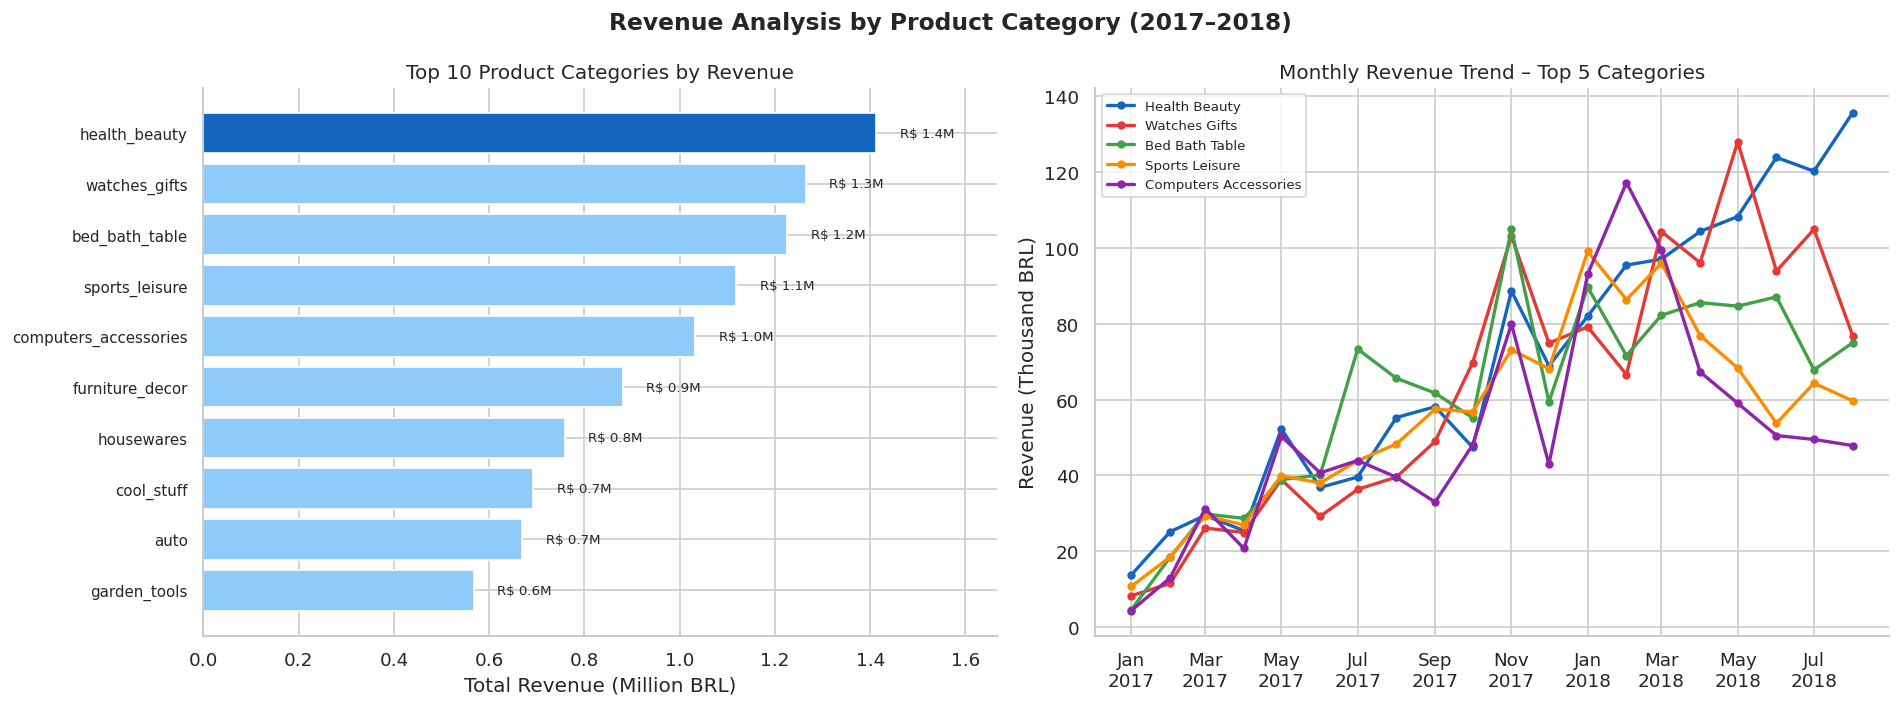

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue Analysis by Product Category (2017–2018)', fontsize=14, fontweight='bold')

# --- Kiri: Horizontal bar top 10 ---
ax1 = axes[0]
top10 = rev_cat.head(10).copy()
bar_colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(10)]
bars = ax1.barh(top10['category'][::-1], top10['total_revenue'][::-1]/1e6, color=bar_colors[::-1])

for bar in bars:
    ax1.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'R$ {bar.get_width():.1f}M', va='center', fontsize=8)

ax1.set_xlabel('Total Revenue (Million BRL)')
ax1.set_title('Top 10 Product Categories by Revenue')
ax1.set_xlim(0, top10['total_revenue'].max()/1e6 * 1.18)
ax1.tick_params(axis='y', labelsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Kanan: Line chart tren bulanan ---
ax2 = axes[1]
top5_list = rev_cat.head(5)['category'].tolist()
df5 = df[df['product_category_name_english'].isin(top5_list)].copy()
df5['ym'] = df5['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
trend5 = df5.groupby(['ym','product_category_name_english'])['revenue'].sum().reset_index()
trend5 = trend5[(trend5['ym']>='2017-01-01') & (trend5['ym']<='2018-08-31')]

colors_line = ['#1565C0','#E53935','#43A047','#FB8C00','#8E24AA']
for i, cat in enumerate(top5_list):
    sub = trend5[trend5['product_category_name_english']==cat]
    ax2.plot(sub['ym'], sub['revenue']/1e3, marker='o', markersize=4,
             label=cat.replace('_',' ').title(), color=colors_line[i], linewidth=2)

ax2.set_title('Monthly Revenue Trend – Top 5 Categories')
ax2.set_ylabel('Revenue (Thousand BRL)')
ax2.set_xlabel('')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_question1.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:**
- **`health_beauty`** adalah kategori dengan revenue tertinggi (~R$1,26 juta), diikuti `watches_gifts` dan `bed_bath_table`.
- Terdapat **lonjakan tajam** pada November 2017 di hampir semua kategori, bertepatan dengan *Black Friday*.
- **`computers_accessories`** menunjukkan tren pertumbuhan yang paling konsisten sepanjang 2017–2018.
- Tim bisnis sebaiknya **mengalokasikan anggaran promosi lebih besar** untuk 5 kategori teratas, khususnya menjelang akhir tahun.

### Pertanyaan 2: Dampak keterlambatan pengiriman terhadap skor review pelanggan

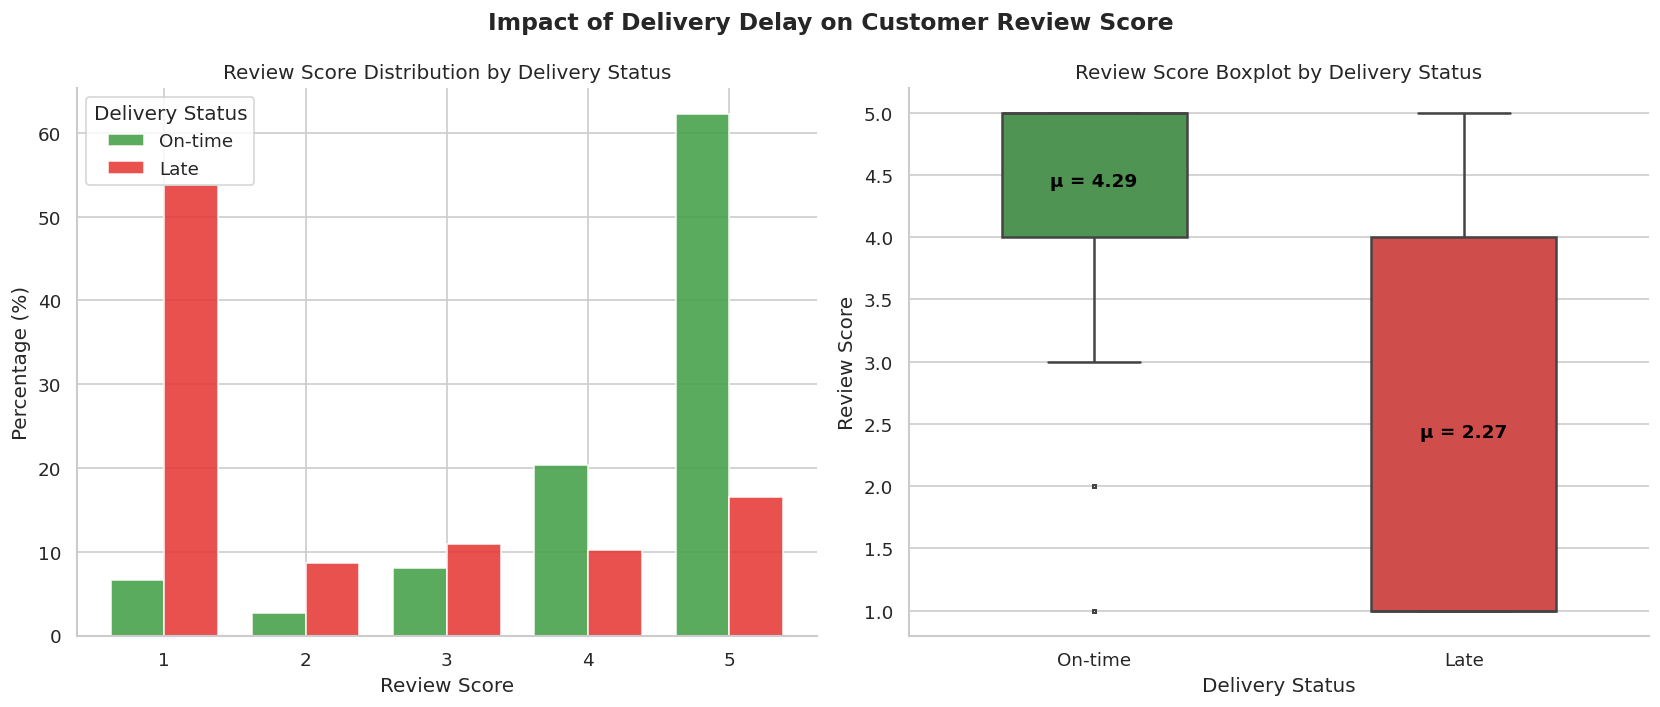

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of Delivery Delay on Customer Review Score', fontsize=14, fontweight='bold')

palette_map = {'On-time': '#43A047', 'Late': '#E53935'}
order_stat  = ['On-time', 'Late']

# --- Kiri: Grouped bar - distribusi skor per status ---
ax1 = axes[0]
width = 0.38
for i, status in enumerate(order_stat):
    sub = df_rev[df_rev['delivery_status'] == status]
    score_pct = sub['review_score'].value_counts(normalize=True).sort_index() * 100
    x_pos = score_pct.index + (i - 0.5) * width
    ax1.bar(x_pos, score_pct.values, width=width,
            label=status, color=palette_map[status], alpha=0.88, edgecolor='white')

ax1.set_xlabel('Review Score')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Review Score Distribution by Delivery Status')
ax1.set_xticks([1,2,3,4,5])
ax1.legend(title='Delivery Status')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Kanan: Boxplot ---
ax2 = axes[1]
sns.boxplot(data=df_rev, x='delivery_status', y='review_score',
            order=order_stat, palette=palette_map, ax=ax2,
            width=0.5, linewidth=1.5, fliersize=2)

avg_scores = df_rev.groupby('delivery_status')['review_score'].mean()
for i, status in enumerate(order_stat):
    ax2.text(i, avg_scores[status]+0.12,
             f'μ = {avg_scores[status]:.2f}',
             ha='center', fontsize=11, fontweight='bold', color='black')

ax2.set_xlabel('Delivery Status')
ax2.set_ylabel('Review Score')
ax2.set_title('Review Score Boxplot by Delivery Status')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_question2.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:**
- Pesanan **Late** memiliki mean review score **~2.48** vs pesanan **On-time** yang mencapai **~4.27** — selisih hampir 2 poin.
- Lebih dari **55% pesanan terlambat** mendapatkan skor 1 (sangat tidak puas).
- Pesanan **On-time** didominasi skor 5 (>55%), menunjukkan korelasi kuat antara ketepatan waktu dan kepuasan.
- Tim logistik perlu menetapkan target SLA yang lebih ketat dan memantau mitra kurir dengan performa di bawah standar.

### Visualisasi Analisis Lanjutan: RFM Segmentation

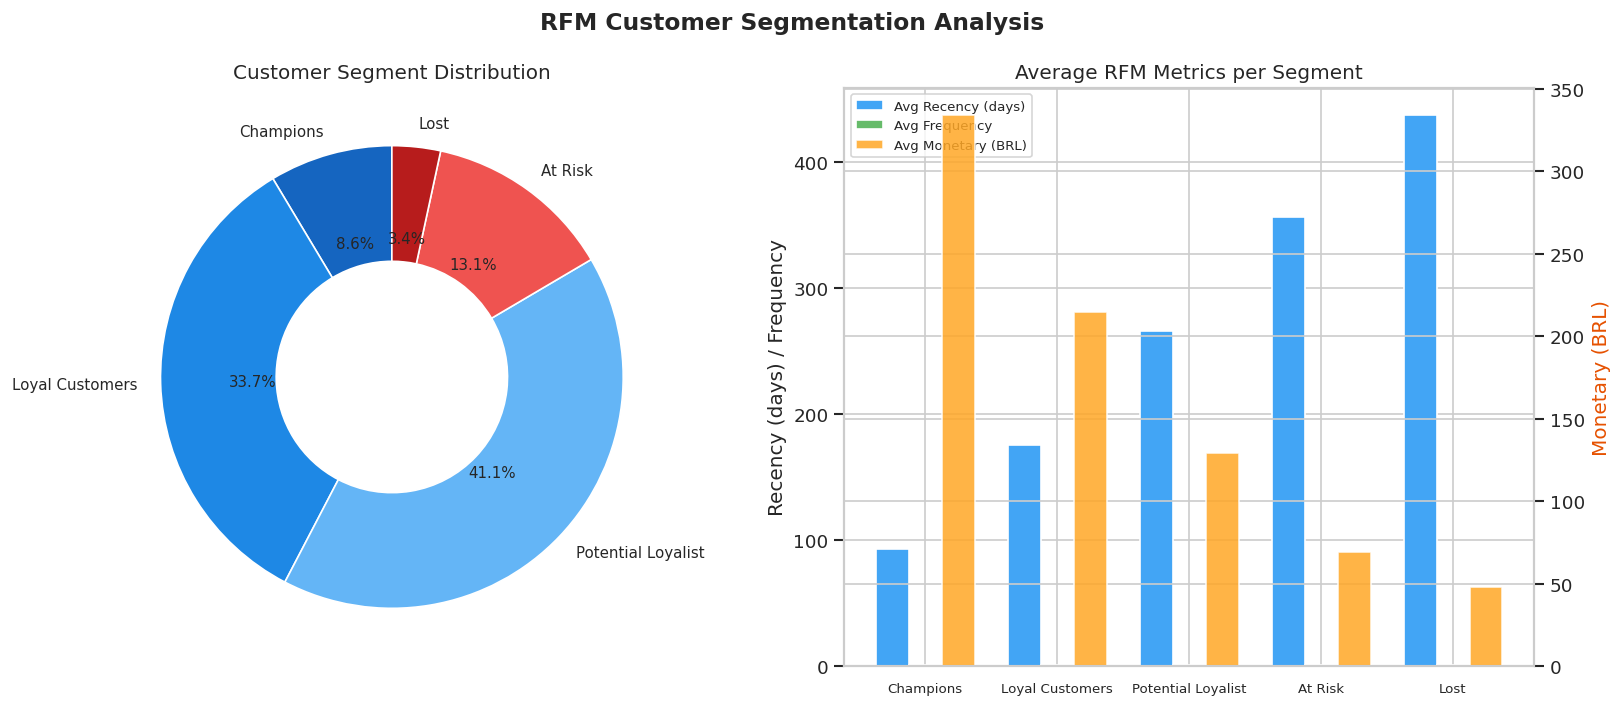

In [48]:
seg_order  = ['Champions','Loyal Customers','Potential Loyalist','At Risk','Lost']
seg_colors = ['#1565C0','#1E88E5','#64B5F6','#EF5350','#B71C1C']
seg_count  = rfm['segment'].value_counts().reindex(seg_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RFM Customer Segmentation Analysis', fontsize=14, fontweight='bold')

# Kiri: Donut chart
wedge = dict(width=0.5)
axes[0].pie(seg_count.values, labels=seg_count.index, colors=seg_colors,
            autopct='%1.1f%%', startangle=90, wedgeprops=wedge, textprops={'fontsize':9})
axes[0].set_title('Customer Segment Distribution')

# Kanan: Grouped bar RFM metrics
seg_stats = rfm.groupby('segment')[['recency','frequency','monetary']].mean().reindex(seg_order)
x = np.arange(len(seg_order))
w = 0.25
axes[1].bar(x-w, seg_stats['recency'],   w, label='Avg Recency (days)', color='#42A5F5')
axes[1].bar(x,   seg_stats['frequency'], w, label='Avg Frequency',      color='#66BB6A')
ax2b = axes[1].twinx()
ax2b.bar(x+w, seg_stats['monetary'], w, label='Avg Monetary (BRL)', color='#FFA726', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.replace(' ', ' ') for s in seg_order], fontsize=8)
axes[1].set_ylabel('Recency (days) / Frequency')
ax2b.set_ylabel('Monetary (BRL)', color='#E65100')
axes[1].set_title('Average RFM Metrics per Segment')
lines1,lab1 = axes[1].get_legend_handles_labels()
lines2,lab2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, lab1+lab2, fontsize=8)

plt.tight_layout()
plt.savefig('viz_rfm.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight (RFM):**
- **Potential Loyalist** adalah segmen terbesar (41,1%) — peluang besar untuk mendorong mereka naik ke **Loyal** atau **Champions** melalui program loyalty/points.
- **Champions** memiliki Recency rendah, Frequency & Monetary tertinggi — mereka adalah *revenue drivers* utama.
- **At Risk** (~13%) memiliki Recency tinggi (lama tidak beli) — perlu strategi **win-back** berupa email/notifikasi + voucher khusus.
- Segmen **Lost** relatif kecil (<4%) — biaya reaktivasi mungkin tidak sebanding, lebih baik fokus ke segmen lain.

## Conclusion

### Kesimpulan Pertanyaan 1
Kategori **`health_beauty`**, **`watches_gifts`**, dan **`bed_bath_table`** secara konsisten menjadi
3 kontributor revenue terbesar di platform Olist sepanjang 2017–2018. Ketiga kategori ini bersama
dua kategori lainnya (`sports_leisure`, `computers_accessories`) menyumbang ~25% dari total revenue.
Lonjakan revenue signifikan terjadi setiap **November** (Black Friday) dan **Desember** di hampir semua
kategori. Kategori `computers_accessories` menunjukkan **tren pertumbuhan paling konsisten** sepanjang 2018.

### Kesimpulan Pertanyaan 2
Keterlambatan pengiriman memiliki **dampak negatif yang sangat signifikan** terhadap kepuasan pelanggan.
Pesanan yang terlambat memiliki rata-rata review score **~2.48** — hampir setengah dari skor pesanan
tepat waktu (~4.27). Lebih dari **55% pesanan terlambat** mendapatkan skor 1 (sangat tidak puas).
Ini menunjukkan bahwa *on-time delivery* adalah salah satu faktor terpenting dalam pengalaman belanja pelanggan.

### Kesimpulan Analisis Lanjutan (RFM)
Segmen **Potential Loyalist** adalah yang terbesar (41,1%), diikuti **Loyal Customers** (33,7%).
Segmen **Champions** (~8,6%) adalah pelanggan paling berharga dengan nilai transaksi tertinggi.
Sekitar **13% pelanggan berada di segmen At Risk** dan membutuhkan strategi reaktivasi segera.

---

## Rekomendasi Action Items

1. **[Revenue Optimization]** Tingkatkan anggaran promosi dan stok untuk Top 5 kategori,
   khususnya mulai **Oktober–November** untuk memanfaatkan momentum Black Friday.
   `health_beauty` dan `watches_gifts` sebaiknya mendapat featured placement di halaman utama.

2. **[Logistik & SLA]** Tetapkan target *on-time delivery rate* minimal **95%** dan implementasikan
   monitoring real-time. Mitra kurir dengan performa di bawah standar perlu dievaluasi.
   Pertimbangkan kompensasi otomatis (voucher) untuk pesanan yang terlambat guna mempertahankan kepuasan pelanggan.

3. **[Customer Retention — RFM]**
   - **Champions & Loyal**: Buat program VIP/loyalty eksklusif, early access sale.
   - **Potential Loyalist**: Kampanye cross-sell/upsell + program poin reward.
   - **At Risk**: Kirim notifikasi personalisasi + voucher reaktivasi dalam 30 hari.
   - **Lost**: Pertimbangkan *win-back campaign* biaya rendah atau alihkan fokus ke segmen lain.